# Importation bibliothèques

In [60]:
import pandas as pd
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys

# Importation dataframes

In [51]:
df = pd.read_csv(r"C:\Users\Utilisateur\Desktop\ProjetCertif\ProjetCertif\DATA\external\donnees_touriste.csv")
df_merged = pd.read_csv(r"C:\Users\Utilisateur\Desktop\ProjetCertif\ProjetCertif\DATA\processed\WorldTravel_ISO.csv")
df_life_quality = pd.read_csv(r"C:\Users\Utilisateur\Desktop\ProjetCertif\ProjetCertif\DATA\processed\life_quality.csv")

In [8]:
df_merged.columns

Index(['Unnamed: 0.1', 'pays', 'code_2L', 'code_3L', 'code_numerique',
       'Unnamed: 0', 'id', 'City', 'country', 'region', 'short_description',
       'latitude', 'longitude', 'budget_level', 'culture', 'adventure',
       'nature', 'beaches', 'nightlife', 'cuisine', 'wellness', 'urban',
       'seclusion', 'Day trip', 'Long trip', 'One week', 'Short trip',
       'Weekend', 'temp_month1_avg', 'temp_month1_max', 'temp_month1_min',
       'temp_month2_avg', 'temp_month2_max', 'temp_month2_min',
       'temp_month3_avg', 'temp_month3_max', 'temp_month3_min',
       'temp_month4_avg', 'temp_month4_max', 'temp_month4_min',
       'temp_month5_avg', 'temp_month5_max', 'temp_month5_min',
       'temp_month6_avg', 'temp_month6_max', 'temp_month6_min',
       'temp_month7_avg', 'temp_month7_max', 'temp_month7_min',
       'temp_month8_avg', 'temp_month8_max', 'temp_month8_min',
       'temp_month9_avg', 'temp_month9_max', 'temp_month9_min',
       'temp_month10_avg', 'temp_month10_max', 't

In [20]:
df.shape

(41, 24)

In [21]:
df_merged.shape

(105, 64)

# MERGE des dataframes

In [14]:
df_merge = pd.merge(df, df_merged, left_on="pays", right_on="code_3L", how="inner")
df_merge.shape

(104, 88)

In [15]:
df_merge.info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 88 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   pays_x                                   104 non-null    str    
 1   Services voyage (% exports de services)  94 non-null     float64
 2   Accès électricité (% pop)                104 non-null    float64
 3   Densité de population (hab/km²)          104 non-null    float64
 4   Pop. dans grandes agglomérations (%)     82 non-null     float64
 5   Accès Internet (% pop)                   103 non-null    float64
 6   PIB par habitant (USD)                   104 non-null    float64
 7   Accès eau potable (% pop)                103 non-null    float64
 8   Médecins (pour 1000 habitants)           103 non-null    float64
 9   Dépenses santé par habitant (USD)        103 non-null    float64
 10  Pauvreté < 3$/jour (% pop)               96 non-null     floa

<Axes: >

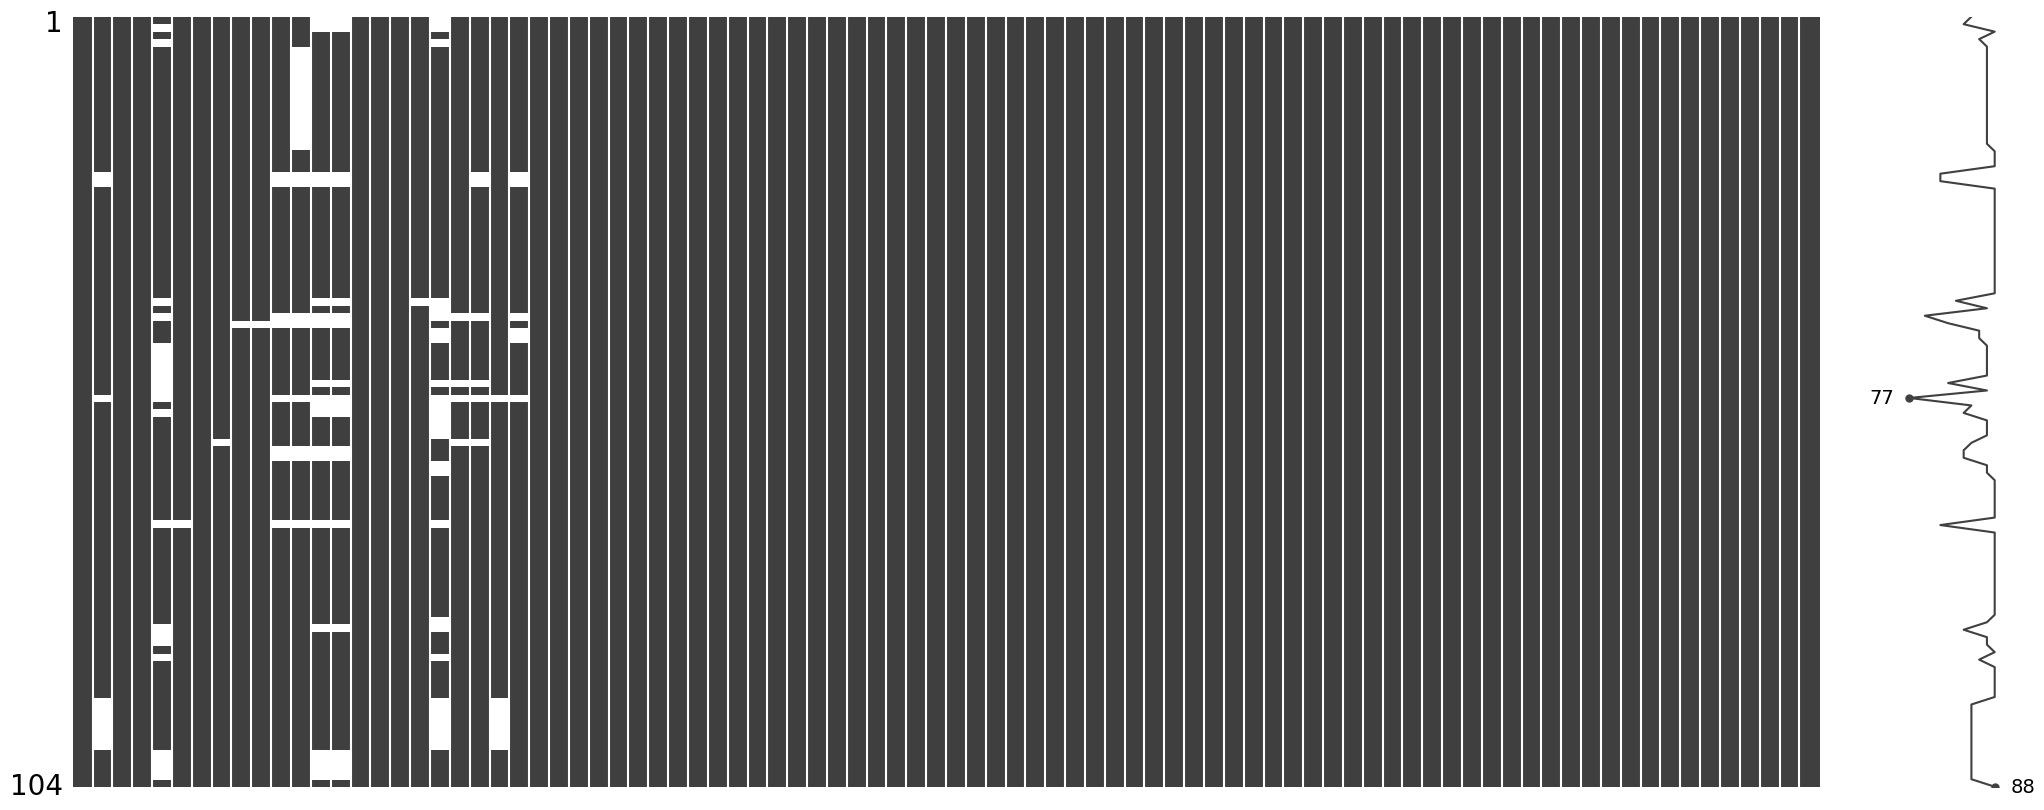

In [19]:
msno.matrix(df_merge)

In [23]:
df_merge[['pays_x', 'pays_y', 'code_3L', 'country']]

,pays_x,pays_y,code_3L,country
0,AGO,angola,AGO,angola
1,BDI,burundi,BDI,burundi
2,BGD,bangladesh,BGD,bangladesh
3,BWA,botswana,BWA,botswana
4,CAN,canada,CAN,canada
...,...,...,...,...
99,VUT,vanuatu,VUT,vanuatu
100,VUT,vanuatu,VUT,vanuatu
101,VUT,vanuatu,VUT,vanuatu
102,WSM,samoa,WSM,samoa


In [24]:
df_maj = df_merge.drop(columns = ['pays_x', 'pays_y', 'code_2L'])

In [26]:
df_maj.columns

Index(['Services voyage (% exports de services)', 'Accès électricité (% pop)',
       'Densité de population (hab/km²)',
       'Pop. dans grandes agglomérations (%)', 'Accès Internet (% pop)',
       'PIB par habitant (USD)', 'Accès eau potable (% pop)',
       'Médecins (pour 1000 habitants)', 'Dépenses santé par habitant (USD)',
       'Pauvreté < 3$/jour (% pop)', 'Pauvreté seuil national (% pop)',
       'Revenu 40% les plus pauvres ($/jour)',
       'Revenu moyen par habitant ($/jour)', 'Espérance de vie (années)',
       'Population rurale (% total)', 'Population urbaine (% total)',
       'Arrivées touristes internationaux (nb)',
       'Départs touristes internationaux (nb)', 'Recettes tourisme (USD)',
       'Recettes tourisme (% exportations)',
       'Recettes voyages touristiques (USD)', 'Dépenses tourisme (USD)',
       'date_maj', 'Unnamed: 0.1', 'code_3L', 'code_numerique', 'Unnamed: 0',
       'id', 'City', 'country', 'region', 'short_description', 'latitude',
       '

# Division de df_maj
Me permet de recupérer les données pour ressembler aux tables de ma BDD

### df_meteo

In [32]:
df_meteo = df_maj[['id', 'City', 'country','code_3L', 'temp_month1_avg', 'temp_month1_max', 'temp_month1_min',
       'temp_month2_avg', 'temp_month2_max', 'temp_month2_min',
       'temp_month3_avg', 'temp_month3_max', 'temp_month3_min',
       'temp_month4_avg', 'temp_month4_max', 'temp_month4_min',
       'temp_month5_avg', 'temp_month5_max', 'temp_month5_min',
       'temp_month6_avg', 'temp_month6_max', 'temp_month6_min',
       'temp_month7_avg', 'temp_month7_max', 'temp_month7_min',
       'temp_month8_avg', 'temp_month8_max', 'temp_month8_min',
       'temp_month9_avg', 'temp_month9_max', 'temp_month9_min',
       'temp_month10_avg', 'temp_month10_max', 'temp_month10_min',
       'temp_month11_avg', 'temp_month11_max', 'temp_month11_min',
       'temp_month12_avg', 'temp_month12_max', 'temp_month12_min']]
df_meteo.head()

,id,City,country,code_3L,temp_month1_avg,temp_month1_max,temp_month1_min,temp_month2_avg,temp_month2_max,temp_month2_min,...,temp_month9_min,temp_month10_avg,temp_month10_max,temp_month10_min,temp_month11_avg,temp_month11_max,temp_month11_min,temp_month12_avg,temp_month12_max,temp_month12_min
0,e8ad2770-6863-4e5c-a993-04884328802e,Luanda,angola,AGO,27.4,31.0,24.7,27.7,31.4,25.0,...,21.2,25.4,28.7,23.2,26.7,29.8,24.3,27.0,30.5,24.4
1,7953a021-a4c4-4fbf-b5a8-92467f8280ed,Bujumbura,burundi,BDI,24.0,28.9,20.3,24.3,29.4,20.5,...,19.9,24.7,30.1,20.1,23.9,28.8,20.0,23.9,28.6,20.0
2,6ee0fe94-2e9b-46ef-8bfc-5e218132332b,Dhaka,bangladesh,BGD,18.7,24.7,14.7,21.8,28.2,17.3,...,26.8,28.0,32.4,25.0,24.6,30.4,20.5,20.5,26.1,16.6
3,778d28df-a4fa-4328-896e-4a9f80216fda,Maun,botswana,BWA,26.6,32.0,21.2,26.1,31.5,20.7,...,20.1,29.3,34.8,23.8,28.7,34.2,23.2,27.5,33.0,22.0
4,73036cda-9134-46fc-a2c6-807782d59dfb,Whistler,canada,CAN,-2.5,0.4,-5.5,-1.8,0.8,-7.2,...,9.9,7.6,11.6,4.4,1.8,5.1,-1.6,-1.8,0.9,-2.5


In [65]:
df_long = pd.wide_to_long(
    df_meteo,
    stubnames=["temp_month"],
    i=["id", "City", "country", "code_3L"],  # identifiants fixes
    j="month",
    sep="",
    suffix=r"\d+_(avg|max|min)"
).reset_index()

In [67]:
df_long.shape
df_long.head()

,id,City,country,code_3L,month,temp_month
0,e8ad2770-6863-4e5c-a993-04884328802e,Luanda,angola,AGO,1_avg,27.4
1,e8ad2770-6863-4e5c-a993-04884328802e,Luanda,angola,AGO,1_max,31.0
2,e8ad2770-6863-4e5c-a993-04884328802e,Luanda,angola,AGO,1_min,24.7
3,e8ad2770-6863-4e5c-a993-04884328802e,Luanda,angola,AGO,2_avg,27.7
4,e8ad2770-6863-4e5c-a993-04884328802e,Luanda,angola,AGO,2_max,31.4


In [71]:
# 1. Transformer en format long
df_melt = df_meteo.melt(
    id_vars = ["id", "City", "country", "code_3L"],
    var_name = "variable",
    value_name = "value"
)

# 2. Extraire mois + type (avg/min/max)
df_melt[["temp", "month", "stat"]] = df_melt["variable"].str.extract(
    r"(temp)_month(\d+)_(avg|max|min)"
)

# 3. Pivot pour remettre avg/min/max en colonnes
df_meteo_final = df_melt.pivot_table(
    index=["City", "country", "code_3L", "month"],
    columns="stat",
    values="value"
).reset_index()

# 4. Nettoyage noms colonnes
df_meteo_final.columns.name = None
df_meteo_final = df_final.rename(columns={
    "avg": "temp_avg",
    "min": "temp_min",
    "max": "temp_max"
})
df_meteo_final.head()

,City,country,code_3L,month,temp_avg,temp_max,temp_min
0,Accra,ghana,GHA,1,28.7,33.3,25.8
1,Accra,ghana,GHA,10,27.3,31.1,24.4
2,Accra,ghana,GHA,11,28.4,32.4,25.2
3,Accra,ghana,GHA,12,28.8,33.2,25.7
4,Accra,ghana,GHA,2,29.1,33.6,26.3


### df_destination

In [75]:
df_destination = df_maj[['City', 'country','code_3L', 'region', 'short_description', 'latitude',
       'longitude']]
df_destination.head()

,City,country,code_3L,region,short_description,latitude,longitude
0,Luanda,angola,AGO,africa,"A bustling port city with vibrant markets, liv...",-8.827270,13.243951
1,Bujumbura,burundi,BDI,africa,A city where vibrant street markets and lush l...,-3.363812,29.367503
2,Dhaka,bangladesh,BGD,asia,"A whirlwind of vibrant street life, bustling m...",23.764386,90.389014
3,Maun,botswana,BWA,africa,"A gateway to the Okavango Delta, offering a se...",-19.986095,23.422435
4,Whistler,canada,CAN,north_america,Snow-capped peaks and lush forests create a se...,50.117190,-122.954302


### df_activites

In [34]:
df_activites = df_maj[['code_3L', 'City','culture', 'adventure', 'nature',
       'beaches', 'nightlife', 'cuisine', 'wellness', 'urban', 'seclusion',]]
df_activites.head()

,code_3L,City,culture,adventure,nature,beaches,nightlife,cuisine,wellness,urban,seclusion
0,AGO,Luanda,3,3,3,3,3,4,2,3,2
1,BDI,Bujumbura,3,3,4,3,2,3,2,2,4
2,BGD,Dhaka,4,2,2,1,3,4,2,3,1
3,BWA,Maun,3,5,5,1,2,3,3,2,4
4,CAN,Whistler,3,5,5,2,3,3,4,2,4


### df_WorldBank 

In [33]:
df_worldbank = df_maj[['code_3L', 'Services voyage (% exports de services)', 'Accès électricité (% pop)',
       'Densité de population (hab/km²)',
       'Pop. dans grandes agglomérations (%)', 'Accès Internet (% pop)',
       'PIB par habitant (USD)', 'Accès eau potable (% pop)',
       'Médecins (pour 1000 habitants)', 'Dépenses santé par habitant (USD)',
       'Pauvreté < 3$/jour (% pop)', 'Pauvreté seuil national (% pop)',
       'Revenu 40% les plus pauvres ($/jour)',
       'Revenu moyen par habitant ($/jour)', 'Espérance de vie (années)',
       'Population rurale (% total)', 'Population urbaine (% total)',
       'Arrivées touristes internationaux (nb)',
       'Départs touristes internationaux (nb)', 'Recettes tourisme (USD)',
       'Recettes tourisme (% exportations)',
       'Recettes voyages touristiques (USD)', 'Dépenses tourisme (USD)',
       'date_maj']]
df_worldbank.head()

,code_3L,Services voyage (% exports de services),Accès électricité (% pop),Densité de population (hab/km²),Pop. dans grandes agglomérations (%),Accès Internet (% pop),PIB par habitant (USD),Accès eau potable (% pop),Médecins (pour 1000 habitants),Dépenses santé par habitant (USD),...,Espérance de vie (années),Population rurale (% total),Population urbaine (% total),Arrivées touristes internationaux (nb),Départs touristes internationaux (nb),Recettes tourisme (USD),Recettes tourisme (% exportations),Recettes voyages touristiques (USD),Dépenses tourisme (USD),date_maj
0,AGO,9.923331,51.1,29.477746,25.285333,44.7581,2916.136633,67.224425,0.244,76.071182,...,64.617000,30.148497,69.851503,218000.0,NaN,1.900000e+07,0.090457,1.600000e+07,6.910000e+08,2026-03-26
1,BDI,2.372476,11.6,533.078271,NaN,11.0784,250.627253,65.806988,0.078,28.140289,...,63.651000,76.446523,23.553477,299000.0,NaN,3.700000e+06,1.570029,3.900000e+06,4.900000e+07,2026-03-26
2,BGD,7.113293,99.5,1319.179797,16.673341,44.5027,2551.017738,98.681668,0.722,53.464325,...,74.672000,67.842153,32.157847,323000.0,1.460000e+06,2.179000e+08,0.566327,2.170000e+08,6.590000e+08,2026-03-26
3,BWA,69.432982,76.0,4.376412,NaN,81.3600,7826.353765,91.723655,0.379,489.596771,...,69.163000,32.978734,67.021266,1830000.0,NaN,2.170000e+08,4.561363,2.110000e+08,9.180000e+07,2026-03-26
4,CAN,29.408235,100.0,4.560798,44.802126,93.9564,54220.328504,98.290504,2.819,6186.652344,...,81.646585,17.474944,82.525056,32430000.0,3.784590e+07,1.999400e+10,3.656701,1.125600e+10,4.124700e+10,2026-03-26


In [100]:
# Réorientation
df_melted = df_worldbank.melt(
    id_vars = ["code_3L"],
    var_name = "variable",
    value_name = "value"
)
df_melted.head()

,code_3L,variable,value
0,AGO,Services voyage (% exports de services),9.923331
1,BDI,Services voyage (% exports de services),2.372476
2,BGD,Services voyage (% exports de services),7.113293
3,BWA,Services voyage (% exports de services),69.432982
4,CAN,Services voyage (% exports de services),29.408235


In [101]:
# 4. Nettoyage noms colonnes
df_melted.columns.name = None
df_wb_final = df_melted.rename(columns={
    "variable": "libele",
    "value": "valeur"
})
df_wb_final.head()

,code_3L,libele,valeur
0,AGO,Services voyage (% exports de services),9.923331
1,BDI,Services voyage (% exports de services),2.372476
2,BGD,Services voyage (% exports de services),7.113293
3,BWA,Services voyage (% exports de services),69.432982
4,CAN,Services voyage (% exports de services),29.408235


In [102]:
sys.path.append(os.path.abspath("../.."))
from src.config import INDICATEURS

In [106]:
df_index = pd.DataFrame(list(INDICATEURS.items()), columns=["code_indicateur", "libele"])
df_index.head()

,code_indicateur,libele
0,SH.H2O.BASW.ZS,Accès eau potable (% pop)
1,SP.DYN.LE00.IN,Espérance de vie (années)
2,SH.MED.PHYS.ZS,Médecins (pour 1000 habitants)
3,SH.XPD.CHEX.PC.CD,Dépenses santé par habitant (USD)
4,EG.ELC.ACCS.ZS,Accès électricité (% pop)


In [105]:
df1 = pd.merge(df_wb_final, df_index, left_on="libele", right_on="libele", how="inner")
df1.head()

,code_3L,libele,valeur,code_indicateur
0,AGO,Services voyage (% exports de services),9.923331,BX.GSR.TRVL.ZS
1,BDI,Services voyage (% exports de services),2.372476,BX.GSR.TRVL.ZS
2,BGD,Services voyage (% exports de services),7.113293,BX.GSR.TRVL.ZS
3,BWA,Services voyage (% exports de services),69.432982,BX.GSR.TRVL.ZS
4,CAN,Services voyage (% exports de services),29.408235,BX.GSR.TRVL.ZS


## Parenthèse visualisation

In [48]:
luxe = df_maj[['budget_level', 'Revenu moyen par habitant ($/jour)', 'Recettes tourisme (USD)',
       'Recettes tourisme (% exportations)',
       'Recettes voyages touristiques (USD)', 'Dépenses tourisme (USD)']]

In [49]:
luxe.describe()

,budget_level,Revenu moyen par habitant ($/jour),Recettes tourisme (USD),Recettes tourisme (% exportations),Recettes voyages touristiques (USD),Dépenses tourisme (USD)
count,104.000000,85.000000,1.000000e+02,98.000000,9.600000e+01,9.800000e+01
mean,1.759615,38.415059,1.035489e+10,9.306940,8.143686e+09,1.219055e+10
std,0.615262,28.491049,1.299365e+10,14.971844,1.138519e+10,1.605619e+10
min,1.000000,2.380000,3.700000e+06,0.090457,3.900000e+06,1.800000e+06
25%,1.000000,10.580000,6.690000e+08,2.840531,2.155000e+08,4.120000e+08
50%,2.000000,35.060000,2.769000e+09,4.804042,1.356000e+09,3.536000e+09
75%,2.000000,66.800000,1.999400e+10,9.296363,1.125600e+10,3.119300e+10
max,3.000000,106.100000,3.595800e+10,93.548215,3.264600e+10,4.124700e+10


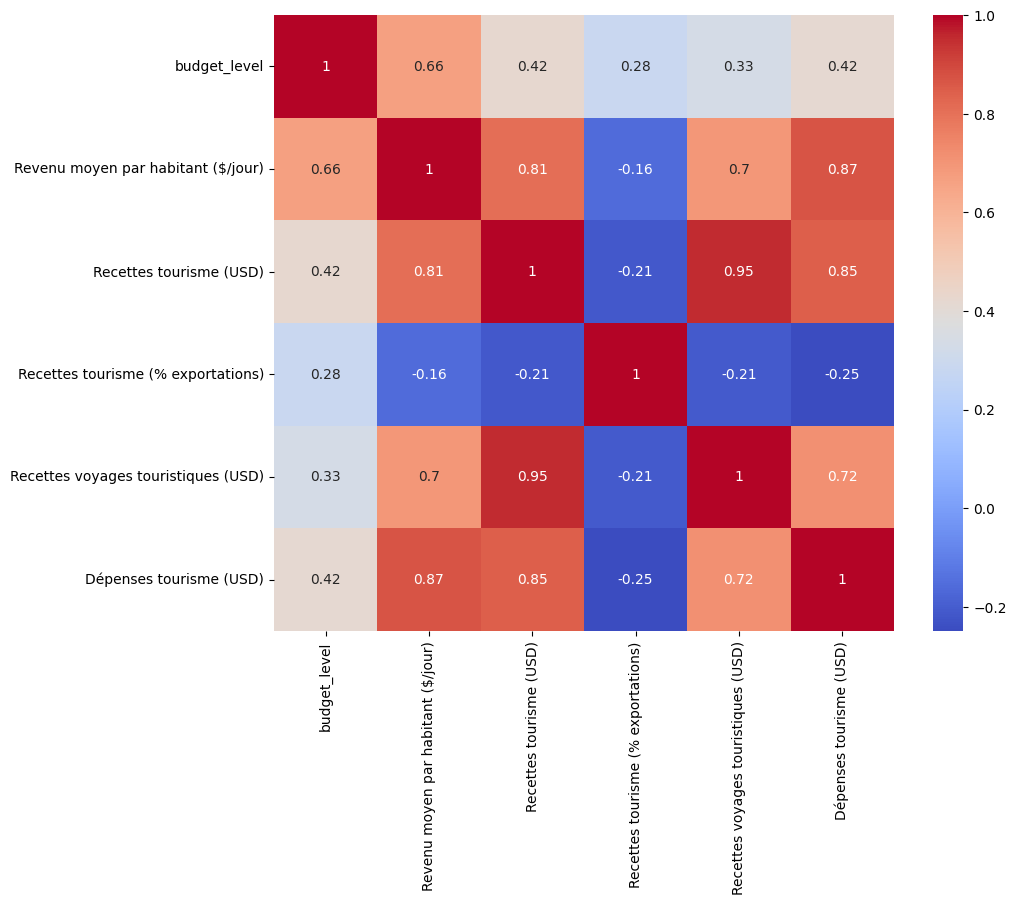

In [50]:
corr = luxe.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

## Visualisation de df_life_quality

In [57]:
df_life_quality.info()

<class 'pandas.DataFrame'>
RangeIndex: 83 entries, 0 to 82
Data columns (total 11 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Classement                             0 non-null      float64
 1   Pays                                   83 non-null     str    
 2   Indice de Qualité de Vie               83 non-null     float64
 3   Indice du Pouvoir d'Achat              83 non-null     float64
 4   Indice de Sécurité                     83 non-null     float64
 5   Indice des soins de santé              83 non-null     float64
 6   Indice du Coût de la Vie               83 non-null     float64
 7   Rapport Prix de l'immobilier/Revenu    83 non-null     float64
 8   Indice du Temps de Trajet dans Trafic  83 non-null     float64
 9   Indice de pollution                    83 non-null     float64
 10  Indice Climatique                      83 non-null     float64
dtypes: float64(10), str

In [53]:
df_life_quality.describe()

,Classement,Indice de Qualité de Vie,Indice du Pouvoir d'Achat,Indice de Sécurité,Indice des soins de santé,Indice du Coût de la Vie,Rapport Prix de l'immobilier/Revenu,Indice du Temps de Trajet dans Trafic,Indice de pollution,Indice Climatique
count,0.0,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000,83.000000
mean,NaN,142.628434,77.040723,60.075301,65.185783,45.894819,13.083855,35.375181,52.294337,77.768554
std,NaN,38.196164,40.120740,13.343464,9.586871,16.454594,6.503937,8.351882,20.778615,16.168736
min,NaN,42.740000,11.010000,25.160000,42.190000,18.820000,2.880000,20.960000,11.900000,20.220000
25%,NaN,113.025000,41.560000,52.315000,57.960000,31.690000,8.820000,29.085000,34.660000,67.800000
50%,NaN,142.740000,71.370000,58.990000,65.960000,42.370000,12.100000,35.310000,56.750000,81.220000
75%,NaN,172.045000,109.605000,70.725000,72.485000,59.715000,15.410000,39.675000,68.650000,89.140000
max,NaN,219.320000,182.530000,84.440000,86.370000,101.100000,39.120000,64.170000,89.370000,99.790000


In [54]:
df_lq = df_life_quality.drop(columns=['Classement'])

In [55]:
df_lq.head()

,Pays,Indice de Qualité de Vie,Indice du Pouvoir d'Achat,Indice de Sécurité,Indice des soins de santé,Indice du Coût de la Vie,Rapport Prix de l'immobilier/Revenu,Indice du Temps de Trajet dans Trafic,Indice de pollution,Indice Climatique
0,Luxembourg,219.32,182.53,65.72,75.33,62.43,8.88,27.18,23.27,82.62
1,Pays-Bas,207.48,124.91,73.58,79.28,63.12,7.69,23.48,21.38,87.01
2,Danemark,205.57,127.20,73.89,78.47,72.27,6.58,27.81,20.75,83.74
3,Oman,204.30,139.80,81.77,65.11,42.37,2.88,20.96,35.04,67.22
4,Suisse,203.95,158.68,73.91,71.73,101.10,10.40,32.93,23.31,82.04


Les données sont un peu _redondantes_ avec les indicateurs **WorldBank**. 
    
Je ne vais **pas les utiliser pour l'entrainement de model** de classification mais je les utiliserais pour un dashboard sur l'app.

# Exportation des données en csv

In [107]:
output_dir = "../DATA/processed"
os.makedirs(output_dir, exist_ok=True)

# Base de données déscriptives
df_meteo_final.to_csv(os.path.join(output_dir, "meteo.csv"), index=False)
df_destination.to_csv(os.path.join(output_dir, "destinations.csv"), index=False)
df1.to_csv(os.path.join(output_dir, "worldbank.csv"), index=False)
df_activites.to_csv(os.path.join(output_dir, "activites.csv"), index=False)

In [77]:
df_destination.columns

Index(['City', 'country', 'code_3L', 'region', 'short_description', 'latitude',
       'longitude'],
      dtype='str')